In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer


In [4]:
data= pd.read_csv("train.csv")
data.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [5]:
data['labels'].unique()

array(['pt', 'bg', 'zh', 'th', 'ru', 'pl', 'ur', 'sw', 'tr', 'es', 'ar',
       'it', 'hi', 'de', 'el', 'nl', 'fr', 'vi', 'en', 'ja'], dtype=object)

In [6]:
df=data[data['labels'].isin(['en','hi','fr','de','es','it','pt','ru','ar','zh'])]

In [7]:
data.shape

(70000, 2)

In [8]:
df.shape

(35000, 2)

In [9]:
language_map = {
    'en': 'English',
    'hi': 'Hindi',
    'fr': 'French',
    'de': 'German',
    'es': 'Spanish',
    'it': 'Italian',
    'pt': 'Portuguese',
    'ru': 'Russian',
    'ar': 'Arabic',
    'zh': 'Chinese'
}

df['language'] = df['labels'].map(language_map)

/tmp/ipykernel_1810/2082262917.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['language'] = df['labels'].map(language_map)


In [10]:
df.head()

,labels,text,language
0,pt,"os chefes de defesa da estónia, letónia, lituâ...",Portuguese
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,Chinese
4,ru,Он увеличил давление .,Russian
10,pt,Duas raças diferentes de cães castanhos e bran...,Portuguese
11,es,Un producto de una calidad y capacidad increíb...,Spanish


In [11]:
df['language'].value_counts()

,count
language,
Portuguese,3500
Chinese,3500
Russian,3500
Spanish,3500
Arabic,3500
Italian,3500
Hindi,3500
German,3500
French,3500


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   labels    35000 non-null  object
 1   text      35000 non-null  object
 2   language  35000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [13]:
df['text'].duplicated().sum()

np.int64(431)

In [14]:
duplicates = df[df.duplicated(subset='text', keep=False)].sort_values('text')

duplicates.head(20)

,labels,text,language
28542,ar,- ولدى المجلس حاليا مشروع نشط لمعالجة معايير ا...,Arabic
13778,ar,- ولدى المجلس حاليا مشروع نشط لمعالجة معايير ا...,Arabic
44424,hi,1822 में शहर की अंग ् रेजी कॉलोनी के वित ् त-प...,Hindi
24676,hi,1822 में शहर की अंग ् रेजी कॉलोनी के वित ् त-प...,Hindi
40619,it,"49 morti, 148 feriti in violenti attacchi in Iraq",Italian
35372,it,"49 morti, 148 feriti in violenti attacchi in Iraq",Italian
65861,pt,"49 mortos, 148 feridos em ataques violentos no...",Portuguese
44401,pt,"49 mortos, 148 feridos em ataques violentos no...",Portuguese
5252,pt,A mulher apanhou o canguru.,Portuguese
11256,pt,A mulher apanhou o canguru.,Portuguese


In [15]:
df.groupby('text')['language'].nunique().sort_values(ascending=False).head(20)

,language
text,
鼠标连接电脑后居然没有反应，这鼠标太差了，我电脑是戴尔外星人，这么高大上的电脑居然用不了，真想骂Amazon。,1
""" American Express "" работает намного лучше для некоторых вещей , потому что вы можете взимать плату за авиабилеты .",1
""" CA "" уехал ночью , а сан-Доро последовали за ним .",1
""" Mus ? ? "" E de la PR ? ? История истории ( 10 место de la шапель ) , экспонаты , которые являются представителями местной жизни во время палеолита , неолита , бронзы , железа и римских веков .",1
""" lisen , लड ़ की , एक ' तुम भी , teodoro जू ' जॉनी शैनन को साफ करते हैं जब वह ' प ् रोड ' पर है .",1
""" nema "" ( هانسون ) بكى",1
""" Безрассудство того , что они узнали давным-давно . "" дон cazar улыбнулся .",1
""" Вы работали на лошадях , и они могут использовать другого wrangler на полигоне .",1
""" Денвер бронко "" на спинах , которые представили салют на межсезонья играх этим летом .",1


In [16]:
df = df.drop_duplicates(subset='text', keep='first')
df.duplicated(subset='text').sum()

np.int64(0)

In [17]:
df.shape

(34569, 3)

In [18]:
df['language'].value_counts()

,count
language,
German,3499
English,3499
Spanish,3498
French,3495
Chinese,3491
Arabic,3464
Hindi,3464
Russian,3463
Portuguese,3350


In [19]:
for language in df['language'].unique():
    print(f"\n--- {language} ---")
    print(df[df['language'] == language]['text'].head(5).to_list())


--- Portuguese ---
['os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.', 'Duas raças diferentes de cães castanhos e brancos brincam na praia.', 'não usa muito o botão de pesquisa, pois não?', 'Jactos do exército matam 38 militantes em ataques aéreos no Noroeste do Paquistão', 'Poderia ter sido um clister?']

--- Chinese ---
['很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！', '只能闲来翻翻 不是太系统 更像是一些传说故事 你杀我我杀你', '这双鞋居然一点都不防水，今天下雨，就在马路上走了十几分钟，鞋尖里面就漏了，这算是质量问题吗？唉，以后还是专柜去买吧。', '有句话说，懂得很多道理，但是仍然过不好这一生。那可能是因为道理还没有说到点子上，或者阐释不够透彻，或者不具备可操作性。但是这本书很多地方都很有启发性，是“老俞道理”的一个集合，也就是如何在对的时间做对的事，这也是所有成功人士的共同具备的素质。俞敏洪从30岁创业，到现在新东方在全国遍地开花，50多岁他又开始二次创业，不仅总是能在对的时间做对的事，还一直在关心支持年轻人。这本书里，从提升幸福感，到制定人生目标；从读书旅行，到合伙创业，其实老俞始终讲的都是“如何过好这一生”的问题，解答每个年轻人在成长阶段中必经的困惑。大学生、职场新鲜人和有过若干社会经验的年轻人，都应该读读这本书，会有不一样的收获', '减震很不错。外观没有色差，但是比我想像的白，经常穿户外的话，恐怕很容易脏。鞋底很软，但是也

In [20]:
df['text_length'] = df['text'].str.len()

In [21]:
df['text_length'].describe()

,text_length
count,34569.000000
mean,122.268246
std,123.649665
min,2.000000
25%,48.000000
50%,86.000000
75%,154.000000
max,2422.000000


In [22]:
df.groupby('language')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
Arabic,3464.0,97.341224,67.660724,2.0,47.00,83.0,134.0,625.0
Chinese,3491.0,50.617015,45.181198,15.0,26.00,37.0,57.5,942.0
English,3499.0,180.114604,177.599128,20.0,66.00,127.0,231.0,1920.0
French,3495.0,159.767096,135.637850,19.0,75.00,127.0,202.0,2422.0
German,3499.0,205.877679,189.903215,20.0,92.00,155.0,255.0,2356.0
Hindi,3464.0,116.040993,80.356990,6.0,58.00,99.0,157.0,876.0
Italian,3346.0,71.264495,43.094955,12.0,44.00,58.0,82.0,464.0
Portuguese,3350.0,68.012239,40.225501,13.0,42.00,56.0,78.0,418.0
Russian,3463.0,117.468669,83.474177,5.0,55.00,99.0,162.0,814.0


In [23]:
df['text_length'] = df['text'].str.len()

df['text_length'].quantile([0.90, 0.95, 0.99, 0.995, 1.0])

,text_length
0.900,246.00
0.950,335.00
0.990,601.28
0.995,765.32
1.000,2422.00


In [24]:
df.sort_values('text_length')[['text', 'language']].head(20)

,text,language
29229,حي,Arabic
62064,Район,Russian
59071,بلع .,Arabic
65005,حاول .,Arabic
48454,घूंट .,Hindi
19522,Это в.,Russian
69370,مذكرة .,Arabic
23683,पड ़ ोस,Hindi
20821,# नाम ?,Hindi
42168,الاسم ?,Arabic


In [25]:
max_len= 650
df= df.drop(['text_length'],axis=1)

In [26]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 41.9 MB/s eta 0:00:00


In [27]:
import emoji

def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

df['text'] = df['text'].apply(remove_emojis)

In [28]:
from sklearn.model_selection import train_test_split
X= df['text']
y= df['language']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
X_train.shape

(27655,)

In [30]:
tokenizer= Tokenizer(char_level=True)
tokenizer.fit_on_texts(X_train)
vocab_size= len(tokenizer.word_index)+1
print(vocab_size)

2753


In [31]:
tokenizer.word_index

{' ': 1,
 'e': 2,
 'a': 3,
 'i': 4,
 'n': 5,
 't': 6,
 's': 7,
 'o': 8,
 'r': 9,
 'l': 10,
 'u': 11,
 'd': 12,
 'c': 13,
 'm': 14,
 'h': 15,
 'p': 16,
 '.': 17,
 'ا': 18,
 'g': 19,
 'b': 20,
 'о': 21,
 'f': 22,
 ',': 23,
 'ل': 24,
 'е': 25,
 'v': 26,
 'а': 27,
 'и': 28,
 'т': 29,
 'क': 30,
 'ा': 31,
 'н': 32,
 'w': 33,
 'ي': 34,
 'y': 35,
 'े': 36,
 'र': 37,
 'k': 38,
 'م': 39,
 'с': 40,
 'ن': 41,
 'р': 42,
 'в': 43,
 'л': 44,
 'ह': 45,
 'و': 46,
 '्': 47,
 'q': 48,
 'ि': 49,
 'z': 50,
 'ت': 51,
 '，': 52,
 'स': 53,
 'न': 54,
 'ं': 55,
 'к': 56,
 'ر': 57,
 'д': 58,
 'м': 59,
 'é': 60,
 'त': 61,
 'म': 62,
 'ी': 63,
 'ع': 64,
 'j': 65,
 'п': 66,
 'ب': 67,
 'د': 68,
 "'": 69,
 'य': 70,
 'ة': 71,
 'प': 72,
 'ы': 73,
 'у': 74,
 'ल': 75,
 'ो': 76,
 'ك': 77,
 'я': 78,
 'ف': 79,
 'ै': 80,
 'ه': 81,
 '的': 82,
 'ق': 83,
 'س': 84,
 'б': 85,
 'ь': 86,
 'ч': 87,
 'г': 88,
 'व': 89,
 'з': 90,
 '-': 91,
 'ح': 92,
 'द': 93,
 '!': 94,
 '0': 95,
 '。': 96,
 'ब': 97,
 'x': 98,
 'ज': 99,
 'ü': 100,
 '不': 10

In [32]:
for char, index in tokenizer.word_index.items():
    print(repr(char), index)

' ' 1
'e' 2
'a' 3
'i' 4
'n' 5
't' 6
's' 7
'o' 8
'r' 9
'l' 10
'u' 11
'd' 12
'c' 13
'm' 14
'h' 15
'p' 16
'.' 17
'ا' 18
'g' 19
'b' 20
'о' 21
'f' 22
',' 23
'ل' 24
'е' 25
'v' 26
'а' 27
'и' 28
'т' 29
'क' 30
'ा' 31
'н' 32
'w' 33
'ي' 34
'y' 35
'े' 36
'र' 37
'k' 38
'م' 39
'с' 40
'ن' 41
'р' 42
'в' 43
'л' 44
'ह' 45
'و' 46
'्' 47
'q' 48
'ि' 49
'z' 50
'ت' 51
'，' 52
'स' 53
'न' 54
'ं' 55
'к' 56
'ر' 57
'д' 58
'м' 59
'é' 60
'त' 61
'म' 62
'ी' 63
'ع' 64
'j' 65
'п' 66
'ب' 67
'د' 68
"'" 69
'य' 70
'ة' 71
'प' 72
'ы' 73
'у' 74
'ल' 75
'ो' 76
'ك' 77
'я' 78
'ف' 79
'ै' 80
'ه' 81
'的' 82
'ق' 83
'س' 84
'б' 85
'ь' 86
'ч' 87
'г' 88
'व' 89
'з' 90
'-' 91
'ح' 92
'द' 93
'!' 94
'0' 95
'。' 96
'ब' 97
'x' 98
'ज' 99
'ü' 100
'不' 101
'1' 102
'ج' 103
'ए' 104
'й' 105
'是' 106
'ग' 107
'х' 108
'了' 109
'ä' 110
'ु' 111
'á' 112
'2' 113
'è' 114
'ж' 115
')' 116
'(' 117
'अ' 118
'一' 119
'ش' 120
'ю' 121
'ذ' 122
'í' 123
'ى' 124
'श' 125
'ط' 126
'ट' 127
'च' 128
'有' 129
'خ' 130
'ू' 131
'à' 132
'ш' 133
'औ' 134
'ç' 135
'ó' 136
'ص' 137
'3' 138
'"' 

In [33]:
import emoji

emoji_chars = []

for char in tokenizer.word_index:
    if emoji.is_emoji(char):
        emoji_chars.append(char)

print(len(emoji_chars))
print(emoji_chars[:20])

0
[]


In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_seq= tokenizer.texts_to_sequences(X_train)
X_test_seq= tokenizer.texts_to_sequences(X_test)

In [35]:
print(X_train_seq[:10])

[[22, 11, 5, 13, 4, 8, 5, 136, 1, 10, 8, 7, 1, 16, 9, 4, 14, 2, 9, 8, 7, 1, 12, 123, 3, 7, 1, 16, 2, 9, 8, 1, 12, 2, 7, 16, 11, 60, 7, 1, 22, 11, 2, 1, 4, 14, 16, 8, 7, 4, 20, 10, 2, 1, 13, 8, 5, 2, 13, 6, 3, 9, 1, 13, 8, 5, 1, 10, 3, 1, 3, 16, 16, 23, 1, 12, 2, 65, 136, 1, 12, 2, 1, 9, 2, 13, 4, 20, 4, 9, 1, 5, 8, 6, 4, 22, 4, 13, 3, 13, 4, 8, 5, 2, 7, 1, 35, 1, 5, 8, 1, 7, 2, 1, 3, 13, 6, 11, 3, 10, 4, 50, 3, 20, 3, 5, 1, 10, 8, 7, 1, 12, 3, 6, 8, 7, 17, 1, 10, 3, 1, 3, 35, 11, 12, 3, 1, 16, 3, 9, 3, 1, 7, 8, 10, 11, 13, 4, 8, 5, 3, 9, 1, 2, 10, 1, 16, 9, 8, 20, 10, 2, 14, 3, 1, 16, 60, 7, 4, 14, 3, 17, 1, 14, 2, 5, 8, 7, 1, 14, 3, 10, 1, 48, 11, 2, 1, 16, 11, 12, 4, 14, 8, 7, 1, 12, 2, 26, 8, 10, 26, 2, 9, 10, 8, 1, 35, 1, 3, 14, 3, 50, 8, 5, 1, 5, 8, 7, 1, 12, 2, 26, 8, 10, 26, 4, 136, 1, 2, 10, 1, 4, 14, 16, 8, 9, 6, 2, 17, 1, 19, 9, 3, 13, 4, 3, 7, 1, 3, 1, 10, 3, 1, 19, 2, 7, 6, 4, 136, 5, 1, 12, 2, 1, 3, 14, 3, 50, 8, 5, 1, 16, 3, 9, 3, 1, 7, 8, 10, 11, 13, 4, 8, 5, 3, 9, 1, 2,

In [36]:
print(len(X_train_seq))

27655


In [37]:
len(X_train_seq[0])

309

In [38]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [39]:
X_train_pad[:5]

array([[ 22,  11,   5, ...,   0,   0,   0],
       [  3,   5,  13, ...,   0,   0,   0],
       [144,  53,  54, ...,   0,   0,   0],
       [230, 248, 232, ...,   0,   0,   0],
       [ 46,  39,  41, ...,   0,   0,   0]], dtype=int32)

In [40]:
print(X_train_pad.shape)
print(X_test_pad.shape)
print(len(X_train_pad[0]))

(27655, 650)
(6914, 650)
650


In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

label_encoder.classes_

array(['Arabic', 'Chinese', 'English', 'French', 'German', 'Hindi',
       'Italian', 'Portuguese', 'Russian', 'Spanish'], dtype=object)

In [42]:
y_train_encoded[:10]

array([9, 6, 5, 1, 0, 8, 0, 3, 1, 3])

In [43]:
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
model= Sequential()
model.add(Embedding(input_dim=vocab_size,output_dim=64))
model.add(LSTM(128))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.build((None,max_len))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 650, 64)        │       176,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,914 (1.08 MB)

 Trainable params: 283,914 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping= EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [48]:
history= model.fit(X_train_pad,
                   y_train_encoded,
                   validation_split=0.2,
                   epochs=100,
                   callbacks=early_stopping)

Epoch 1/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.1035 - loss: 2.3012 - val_accuracy: 0.0989 - val_loss: 2.3073
Epoch 2/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1021 - loss: 2.2957 - val_accuracy: 0.0987 - val_loss: 2.2944
Epoch 3/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.1034 - loss: 2.2947 - val_accuracy: 0.0993 - val_loss: 2.2949
Epoch 4/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1045 - loss: 2.3001 - val_accuracy: 0.1005 - val_loss: 2.2939
Epoch 5/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.1046 - loss: 2.2940 - val_accuracy: 0.1020 - val_loss: 2.2922
Epoch 6/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1048 - loss: 2.2929 - val_accuracy: 0.1034 - val_loss: 2.2925
Epoch 7/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1039 - loss: 2.2931 - val_accuracy: 0.1036 - val_loss: 2.2903
Epoch 8/100
692/692 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.2431 - loss: 1

In [49]:
loss,acc= model.evaluate(X_test_pad,y_test_encoded)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9905 - loss: 0.0501
Test Loss: 0.0501
Test Accuracy: 0.9905


In [50]:
model.save("language_detection_model.keras")

In [51]:
def preprocess_text(text,max_len,tokenizer):
    text = emoji.replace_emoji(text,'')
    text_seq = tokenizer.texts_to_sequences([text])
    text_pad = pad_sequences(text_seq, maxlen=max_len, padding='post', truncating='post')
    return text_pad

In [52]:
def predict_language(text,max_len,tokenizer,model,label_encoder):
    text_pad= preprocess_text(text,max_len,tokenizer)
    prediction= model.predict(text_pad,verbose=0)
    predicted_label= np.argmax(prediction)
    predicted_language= label_encoder.inverse_transform([predicted_label])[0]
    confidence= np.max(prediction)
    return predicted_language,confidence


In [65]:
text = "Heyy!! How r u doing today 😊"
predicted_language, confidence = predict_language(text, max_len, tokenizer, model, label_encoder)
print(f"The predicted language is: {predicted_language}")
print(f"Confidence: {confidence:.4f}")

The predicted language is: English
Confidence: 0.9997


In [66]:
y_pred_prob = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       693
     Chinese       1.00      1.00      1.00       698
     English       0.99      0.99      0.99       700
      French       0.98      0.99      0.99       699
      German       1.00      0.99      0.99       700
       Hindi       1.00      1.00      1.00       693
     Italian       0.98      0.99      0.98       669
  Portuguese       0.96      0.97      0.97       670
     Russian       1.00      1.00      1.00       692
     Spanish       0.99      0.98      0.99       700

    accuracy                           0.99      6914
   macro avg       0.99      0.99      0.99      6914
weighted avg       0.99      0.99      0.99      6914



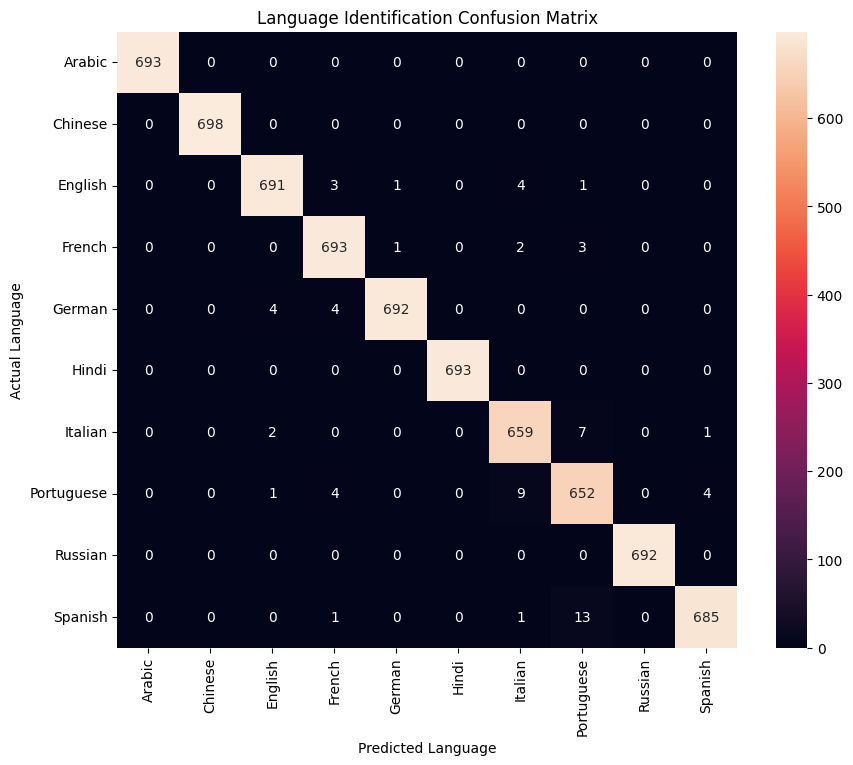

In [68]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Language Identification Confusion Matrix")

plt.show()

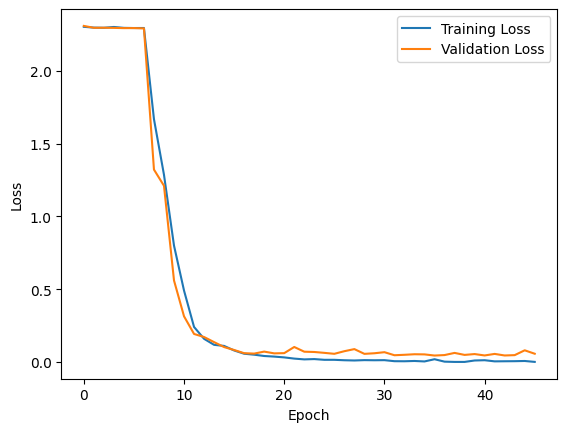

In [69]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

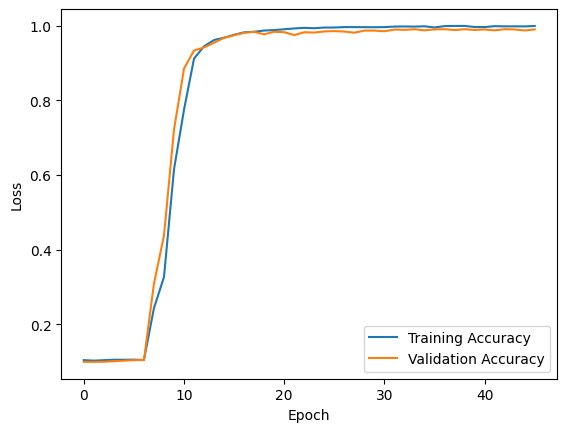

In [71]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [75]:
import pickle
with open('language_detection_tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

with open('language_detection_label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)


In [74]:
with open('language_detection_config.pkl', 'wb') as file:
    pickle.dump({
        'max_len': max_len,
        'vocab_size': vocab_size
    }, file)